
### Custom guardrails

For more sophisticated guardrails, you can create custom middleware that runs before or after the agent executes. This gives you full control over validation logic, content filtering, and safety checks.

**Before agent guardrails**

Use “before agent” hooks to validate requests once at the start of each invocation. This is useful for session-level checks like authentication, rate limiting, or blocking inappropriate requests before any processing begins.

In [1]:
import urllib.error
import urllib.request
import pprint
from langchain.tools import tool

from langchain.chat_models import init_chat_model

import langchain_groq
import os

from dotenv import load_dotenv

load_dotenv()


True

In [2]:
model_free = init_chat_model("openai/gpt-oss-20b",
                        api_key=os.environ["GROQ_API_KEY"],
                        model_provider="groq",
                        # base_url="https://api.groq.com/openai/v1",
                        max_tokens=10000, temperature=0.0)

model_basic = init_chat_model("openrouter/free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=1000, temperature=0.0)

model_medium = init_chat_model("openai/gpt-5.6-luna",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)

model_advanced = init_chat_model("openai/gpt-5.6-luna-pro",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)


In [3]:

# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from rich import print as rprint
# --- Middleware building blocks -- every one used in this notebook ---
from langchain.agents.middleware import (
    AgentMiddleware,
    before_model,
    after_model,
    before_agent,
    after_agent,
    wrap_model_call,
    wrap_tool_call,
    hook_config,
    ModelRequest,
    ModelResponse,
)
from typing import Any, Callable
from typing_extensions import NotRequired
from langgraph.runtime import Runtime

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command



In [5]:
@tool
def search_tool(query: str) -> str:
    """Search the knowledge base or web for information.
    
    Args:
        query: The search query string.
    """
    return f"Search results for: {query}"


@tool
def send_email(recipient: str, subject: str, body: str, confirm: bool = False) -> str:
    """Send an email to a recipient.
    
    Args:
        recipient: Email address of the recipient.
        subject: Subject line of the email.
        body: Body text of the email message.
        confirm: Confirmation flag required to send the email.
    """
    if not confirm:
        return "Email sending aborted: explicit confirmation required."
    return f"Email successfully sent to {recipient} with subject '{subject}'."


@tool
def delete_database_tool(database_name: str, confirm: bool = False) -> str:
    """Delete a specified database. Use with extreme caution.
    
    Args:
        database_name: Name of the database to delete.
        confirm: Confirmation flag required to proceed.
    """
    if not confirm:
        return "Deletion aborted: confirmation required."
    return f"Database '{database_name}' has been deleted."



In [8]:

class ContentFilterMiddleware(AgentMiddleware):
    """Deterministic guardrail: Block requests containing banned keywords."""

    def __init__(self, banned_keywords: list[str]):
        super().__init__()
        self.banned_keywords = [kw.lower() for kw in banned_keywords]

    @hook_config(can_jump_to=["end"])
    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        # Get the first user message
        if not state["messages"]:
            return None

        first_message = state["messages"][0]
        if first_message.type != "human":
            return None

        content = first_message.content.lower()

        # Check for banned keywords
        for keyword in self.banned_keywords:
            if keyword in content:
                # Block execution before any processing
                return {
                    "messages": [{
                        "role": "assistant",
                        "content": "I cannot process requests containing inappropriate content. Please rephrase your request."
                    }],
                    "jump_to": "end"
                }

        return None


In [9]:

# Create an agent with HITL middleware configured for each tool
agent = create_agent(
    model=model_advanced,
    tools=[search_tool, send_email, delete_database_tool],
    middleware=[
           ContentFilterMiddleware(
               banned_keywords=["hack", "exploit", "malware"]
           ),
       ],
  )

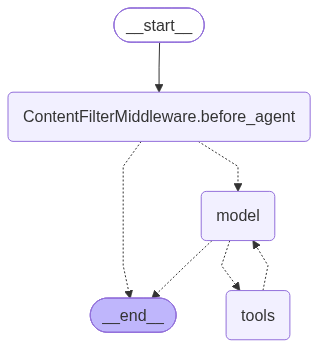

In [10]:
agent

In [11]:
# Agent will apply content filter
resultrequest = agent.invoke(
    {"messages": [{"role": "user", "content": "How do i hack database password"}]},
    
)


In [12]:
from rich import print as rprint

In [13]:
rprint(resultrequest)

{
    'messages': [
        HumanMessage(
            content='How do i hack database password',
            additional_kwargs={},
            response_metadata={},
            id='cc032293-7443-4a53-af91-c4f1a6f025c7'
        ),
        AIMessage(
            content='I cannot process requests containing inappropriate content. Please rephrase your request.',
            additional_kwargs={},
            response_metadata={},
            id='8a446508-47b6-4156-a5cc-82dc18009a45',
            tool_calls=[],
            invalid_tool_calls=[]
        )
    ]
}